# Post-Hoc Multiple Comparison Analysis — Tukey HSD
## Cross-Platform LLM Reasoning Evaluation

This notebook addresses Reviewer #2's concern regarding the absence of
post-hoc multiple comparison testing following ANOVA.

It runs **Tukey HSD** (Honestly Significant Difference) pairwise comparisons
for both evaluation configurations reported in the paper:

| Configuration | Models | Problems |
|---|---|---|
| University Cluster | 7 | 79 |
| Nebius AI Studio | 9 | 79 |

Tukey HSD controls the family-wise error rate (FWER) at α = 0.05
across **all** pairwise comparisons simultaneously — the standard
companion to a significant one-way ANOVA.

### Outputs
1. Full pairwise Tukey HSD tables (adjusted p-values, mean differences)
2. Heatmap visualisations of adjusted p-values
3. Compact letter display (CLD) summary
4. LaTeX-ready tables for the manuscript
5. Downloadable JSON with all results

---
### Data upload
Upload `data.zip` — the flat folder of renamed JSON result files:
```
data/
  Phi-3-mini-4k-instruct_79problems.json          ← UC cluster files
  Phi-4-mini-instruct_79problems.json
  ...  (7 files ending in _79problems.json)
  reasoning_evaluation_results_Hermes-4-70B_..._79.json   ← Nebius files
  ...  (9 files matching reasoning_evaluation_results_*_79.json)
```

---
## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import json, os, zipfile, io
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "statsmodels"])
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("✓ Dependencies loaded")

✓ Dependencies loaded


---
## 2. Upload data.zip and Load Files

In [ ]:
from google.colab import files as colab_files

# ── Filename → display label mappings ────────────────────────────────────
UC_FILES = {
    'Phi-3-mini-4k-instruct_79problems.json'    : 'Phi-3-mini',
    'Phi-4-mini-instruct_79problems.json'        : 'Phi-4-mini',
    'Meta-Llama-3.1-8B-Instruct_79problems.json' : 'LLaMA-3.1-8B',
    'Phi-3.5-MoE-instruct_79problems.json'       : 'Phi-3.5-MoE',
    'Qwen2-7B-Instruct_79problems.json'          : 'Qwen2-7B',
    'falcon-mamba-7b-instruct_79problems.json'   : 'Falcon-Mamba-7B',
    'Mistral-7B-Instruct-v0.1_79problems.json'   : 'Mistral-7B',
}

NEBIUS_FILES = {
    'reasoning_evaluation_results_Hermes-4-70B_79.json'                  : 'Hermes-4-70B',
    'reasoning_evaluation_results_Hermes-4-405B_79.json'                 : 'Hermes-4-405B',
    'reasoning_evaluation_results_Meta-Llama-3.1-405B-Instruct_79.json'  : 'LLaMA-3.1-405B',
    'reasoning_evaluation_results_Llama-3.3-70B-Instruct_79.json'        : 'LLaMA-3.3-70B',
    'reasoning_evaluation_results_Qwen3-235B-A22B-Instruct-2507_79.json' : 'Qwen3-235B',
    'reasoning_evaluation_results_Qwen3-30B-A3B-Instruct-2507_79.json'   : 'Qwen3-30B',
    'reasoning_evaluation_results_DeepSeek-R1-0528_79.json'              : 'DeepSeek-R1',
    'reasoning_evaluation_results_gpt-oss-20b_79.json'                   : 'GPT-OSS-20B',
    'reasoning_evaluation_results_gpt-oss-120b_79.json'                  : 'GPT-OSS-120B',
}

def load_scores_from_zip(zip_bytes, file_map):
    """Extract per-problem average_score for each model from the flat data.zip."""
    scores = {}
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        # Build basename -> full zip path index (ignore macOS metadata)
        available = {
            os.path.basename(n): n
            for n in zf.namelist()
            if not n.startswith('__MACOSX') and n.endswith('.json')
        }
        for fname, label in file_map.items():
            if fname in available:
                with zf.open(available[fname]) as f:
                    d = json.load(f)
                evals = d.get('evaluations', [])
                s = [e['average_score'] for e in evals if e and 'average_score' in e]
                scores[label] = s
                print(f"  ✓ {label:<22}  n={len(s):>2}  mean={np.mean(s):.4f}")
            else:
                print(f"  ✗ NOT FOUND: {fname}")
    return scores

print("📤 Upload data.zip ...")
uploaded  = colab_files.upload()
zip_bytes = next(iter(uploaded.values()))

print("\n── University Cluster (79 problems) ──")
uc_scores = load_scores_from_zip(zip_bytes, UC_FILES)

print("\n── Nebius AI Studio (79 problems) ──")
nebius_scores = load_scores_from_zip(zip_bytes, NEBIUS_FILES)

print("\n✓ All data loaded")

📤 Upload data.zip ...


Saving data.zip to data.zip

── University Cluster (79 problems) ──
  ✓ Phi-3-mini              n=79  mean=0.5653
  ✓ Phi-4-mini              n=79  mean=0.5600
  ✓ LLaMA-3.1-8B            n=79  mean=0.5509
  ✓ Phi-3.5-MoE             n=79  mean=0.5286
  ✓ Qwen2-7B                n=79  mean=0.5140
  ✓ Falcon-Mamba-7B         n=79  mean=0.4990
  ✓ Mistral-7B              n=79  mean=0.3884

── Nebius AI Studio (79 problems) ──
  ✓ Hermes-4-70B            n=79  mean=0.5984
  ✓ Hermes-4-405B           n=79  mean=0.5726
  ✓ LLaMA-3.1-405B          n=79  mean=0.5602
  ✓ LLaMA-3.3-70B           n=79  mean=0.5158
  ✓ Qwen3-235B              n=79  mean=0.4868
  ✓ Qwen3-30B               n=79  mean=0.4771
  ✓ DeepSeek-R1             n=79  mean=0.4568
  ✓ GPT-OSS-20B             n=57  mean=0.4060
  ✓ GPT-OSS-120B            n=66  mean=0.4042

✓ All data loaded


---
## 3. Helper Functions

In [ ]:
def run_anova(scores_dict):
    F, p = stats.f_oneway(*scores_dict.values())
    return float(F), float(p)

def run_tukey(scores_dict):
    flat_scores, flat_labels = [], []
    for label, s in scores_dict.items():
        flat_scores.extend(s)
        flat_labels.extend([label] * len(s))
    res = pairwise_tukeyhsd(
        endog=np.array(flat_scores),
        groups=np.array(flat_labels),
        alpha=0.05
    )
    df = pd.DataFrame(
        data=res._results_table.data[1:],
        columns=['Model A','Model B','Mean Diff','p-adj','CI Lower','CI Upper','Reject H0']
    )
    for c in ['Mean Diff','p-adj','CI Lower','CI Upper']:
        df[c] = df[c].astype(float)
    df['Sig.'] = df['p-adj'].apply(
        lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    )
    return df

def cohens_d(a, b):
    a, b = np.array(a), np.array(b)
    pooled = np.sqrt((np.std(a,ddof=1)**2 + np.std(b,ddof=1)**2) / 2)
    return float((np.mean(a)-np.mean(b))/pooled) if pooled>0 else float('nan')

def compact_letter_display(sorted_models, tukey_df):
    ns = set()
    for _, row in tukey_df.iterrows():
        if not bool(row['Reject H0']):
            ns.add((row['Model A'], row['Model B']))
            ns.add((row['Model B'], row['Model A']))
    groups, assigned = [], {m: [] for m in sorted_models}
    for m in sorted_models:
        placed = False
        for g_idx, grp in enumerate(groups):
            if all((m, mem) in ns for mem in grp):
                grp.append(m)
                assigned[m].append(chr(ord('a')+g_idx))
                placed = True; break
        if not placed:
            groups.append([m])
            assigned[m].append(chr(ord('a')+len(groups)-1))
    return assigned

print("✓ Helpers ready")

✓ Helpers ready


---
## 4. University Cluster — ANOVA + Tukey HSD

In [ ]:
uc_sorted = dict(sorted(uc_scores.items(), key=lambda x: np.mean(x[1]), reverse=True))

F_uc, p_uc = run_anova(uc_sorted)
print("University Cluster — One-Way ANOVA")
print(f"  F = {F_uc:.4f},  p = {p_uc:.2e}")
verdict = 'warranted' if p_uc < 0.05 else 'reported for completeness'
print(f"  → {'Significant' if p_uc<0.05 else 'Not significant'}: post-hoc {verdict}\n")

tukey_uc = run_tukey(uc_sorted)
cld_uc   = compact_letter_display(list(uc_sorted.keys()), tukey_uc)

n_sig_uc = int((tukey_uc['Reject H0']==True).sum())
print(f"Total pairs: {len(tukey_uc)}  |  Significant: {n_sig_uc}  |  Non-significant: {len(tukey_uc)-n_sig_uc}\n")

print("=== SIGNIFICANT PAIRS ===")
display(tukey_uc[tukey_uc['Reject H0']==True].sort_values('p-adj')
        [['Model A','Model B','Mean Diff','p-adj','CI Lower','CI Upper','Sig.']])
print("\n=== NON-SIGNIFICANT PAIRS ===")
display(tukey_uc[tukey_uc['Reject H0']==False].sort_values('p-adj')
        [['Model A','Model B','Mean Diff','p-adj','CI Lower','CI Upper','Sig.']])

print("\nCompact Letter Display:")
for m in uc_sorted:
    print(f"  {m:<22} mean={np.mean(uc_sorted[m]):.4f}  group={''.join(cld_uc[m])}")

University Cluster — One-Way ANOVA
  F = 5.4907,  p = 1.56e-05
  → Significant: post-hoc warranted

Total pairs: 21  |  Significant: 6  |  Non-significant: 15

=== SIGNIFICANT PAIRS ===


,Model A,Model B,Mean Diff,p-adj,CI Lower,CI Upper,Sig.
11,Mistral-7B,Phi-3-mini,0.1769,0.0000,0.0680,0.2859,***
13,Mistral-7B,Phi-4-mini,0.1717,0.0001,0.0627,0.2806,***
6,LLaMA-3.1-8B,Mistral-7B,-0.1626,0.0002,-0.2715,-0.0536,***
12,Mistral-7B,Phi-3.5-MoE,0.1402,0.0029,0.0313,0.2492,**
14,Mistral-7B,Qwen2-7B,0.1256,0.0122,0.0167,0.2346,*
1,Falcon-Mamba-7B,Mistral-7B,-0.1106,0.0439,-0.2196,-0.0017,*



=== NON-SIGNIFICANT PAIRS ===


,Model A,Model B,Mean Diff,p-adj,CI Lower,CI Upper,Sig.
2,Falcon-Mamba-7B,Phi-3-mini,0.0663,0.5480,-0.0426,0.1753,ns
4,Falcon-Mamba-7B,Phi-4-mini,0.0610,0.6443,-0.0479,0.1700,ns
0,Falcon-Mamba-7B,LLaMA-3.1-8B,0.0519,0.7959,-0.0570,0.1609,ns
17,Phi-3-mini,Qwen2-7B,-0.0513,0.8053,-0.1603,0.0576,ns
20,Phi-4-mini,Qwen2-7B,-0.0461,0.8737,-0.1550,0.0629,ns
10,LLaMA-3.1-8B,Qwen2-7B,-0.0369,0.9531,-0.1459,0.0720,ns
15,Phi-3-mini,Phi-3.5-MoE,-0.0367,0.9547,-0.1456,0.0723,ns
18,Phi-3.5-MoE,Phi-4-mini,0.0314,0.9790,-0.0775,0.1404,ns
3,Falcon-Mamba-7B,Phi-3.5-MoE,0.0296,0.9845,-0.0793,0.1386,ns
8,LLaMA-3.1-8B,Phi-3.5-MoE,-0.0223,0.9966,-0.1313,0.0866,ns



Compact Letter Display:
  Phi-3-mini             mean=0.5653  group=a
  Phi-4-mini             mean=0.5600  group=a
  LLaMA-3.1-8B           mean=0.5509  group=a
  Phi-3.5-MoE            mean=0.5286  group=a
  Qwen2-7B               mean=0.5140  group=a
  Falcon-Mamba-7B        mean=0.4990  group=a
  Mistral-7B             mean=0.3884  group=b


---
## 5. Nebius AI Studio — ANOVA + Tukey HSD

In [ ]:
nebius_sorted = dict(sorted(nebius_scores.items(), key=lambda x: np.mean(x[1]), reverse=True))

F_neb, p_neb = run_anova(nebius_sorted)
print("Nebius AI Studio — One-Way ANOVA")
print(f"  F = {F_neb:.4f},  p = {p_neb:.2e}")
verdict = 'warranted' if p_neb < 0.05 else 'reported for completeness'
print(f"  → {'Significant' if p_neb<0.05 else 'Not significant'}: post-hoc {verdict}\n")

tukey_neb = run_tukey(nebius_sorted)
cld_neb   = compact_letter_display(list(nebius_sorted.keys()), tukey_neb)

n_sig_neb = int((tukey_neb['Reject H0']==True).sum())
print(f"Total pairs: {len(tukey_neb)}  |  Significant: {n_sig_neb}  |  Non-significant: {len(tukey_neb)-n_sig_neb}\n")

print("=== SIGNIFICANT PAIRS ===")
display(tukey_neb[tukey_neb['Reject H0']==True].sort_values('p-adj')
        [['Model A','Model B','Mean Diff','p-adj','CI Lower','CI Upper','Sig.']])
print("\n=== NON-SIGNIFICANT PAIRS ===")
display(tukey_neb[tukey_neb['Reject H0']==False].sort_values('p-adj')
        [['Model A','Model B','Mean Diff','p-adj','CI Lower','CI Upper','Sig.']])

print("\nCompact Letter Display:")
for m in nebius_sorted:
    print(f"  {m:<22} mean={np.mean(nebius_sorted[m]):.4f}  group={''.join(cld_neb[m])}")

Nebius AI Studio — One-Way ANOVA
  F = 6.4885,  p = 3.72e-08
  → Significant: post-hoc warranted

Total pairs: 36  |  Significant: 9  |  Non-significant: 27

=== SIGNIFICANT PAIRS ===


,Model A,Model B,Mean Diff,p-adj,CI Lower,CI Upper,Sig.
10,GPT-OSS-120B,Hermes-4-70B,0.1941,0.0000,0.0737,0.3146,***
16,GPT-OSS-20B,Hermes-4-70B,0.1924,0.0001,0.0669,0.3179,***
9,GPT-OSS-120B,Hermes-4-405B,0.1683,0.0005,0.0479,0.2888,***
15,GPT-OSS-20B,Hermes-4-405B,0.1666,0.0013,0.0411,0.2921,**
11,GPT-OSS-120B,LLaMA-3.1-405B,0.1560,0.0020,0.0355,0.2764,**
3,DeepSeek-R1,Hermes-4-70B,0.1416,0.0044,0.0267,0.2565,**
17,GPT-OSS-20B,LLaMA-3.1-405B,0.1542,0.0045,0.0287,0.2797,**
29,Hermes-4-70B,Qwen3-30B,-0.1213,0.0296,-0.2362,-0.0064,*
2,DeepSeek-R1,Hermes-4-405B,0.1158,0.0466,0.0009,0.2307,*



=== NON-SIGNIFICANT PAIRS ===


,Model A,Model B,Mean Diff,p-adj,CI Lower,CI Upper,Sig.
28,Hermes-4-70B,Qwen3-235B,-0.1116,0.0647,-0.2265,0.0033,ns
12,GPT-OSS-120B,LLaMA-3.3-70B,0.1116,0.0945,-0.0088,0.2320,ns
4,DeepSeek-R1,LLaMA-3.1-405B,0.1034,0.1172,-0.0115,0.2183,ns
18,GPT-OSS-20B,LLaMA-3.3-70B,0.1099,0.1412,-0.0156,0.2354,ns
25,Hermes-4-405B,Qwen3-30B,-0.0955,0.1943,-0.2104,0.0194,ns
24,Hermes-4-405B,Qwen3-235B,-0.0858,0.3289,-0.2007,0.0291,ns
32,LLaMA-3.1-405B,Qwen3-30B,-0.0831,0.3741,-0.1980,0.0318,ns
27,Hermes-4-70B,LLaMA-3.3-70B,-0.0825,0.3838,-0.1974,0.0324,ns
13,GPT-OSS-120B,Qwen3-235B,0.0825,0.4517,-0.0379,0.2030,ns
19,GPT-OSS-20B,Qwen3-235B,0.0808,0.5412,-0.0447,0.2063,ns



Compact Letter Display:
  Hermes-4-70B           mean=0.5984  group=a
  Hermes-4-405B          mean=0.5726  group=a
  LLaMA-3.1-405B         mean=0.5602  group=a
  LLaMA-3.3-70B          mean=0.5158  group=a
  Qwen3-235B             mean=0.4868  group=a
  Qwen3-30B              mean=0.4771  group=b
  DeepSeek-R1            mean=0.4568  group=b
  GPT-OSS-20B            mean=0.4060  group=b
  GPT-OSS-120B           mean=0.4042  group=b


---
## 6. Heatmaps of Tukey-Adjusted p-Values

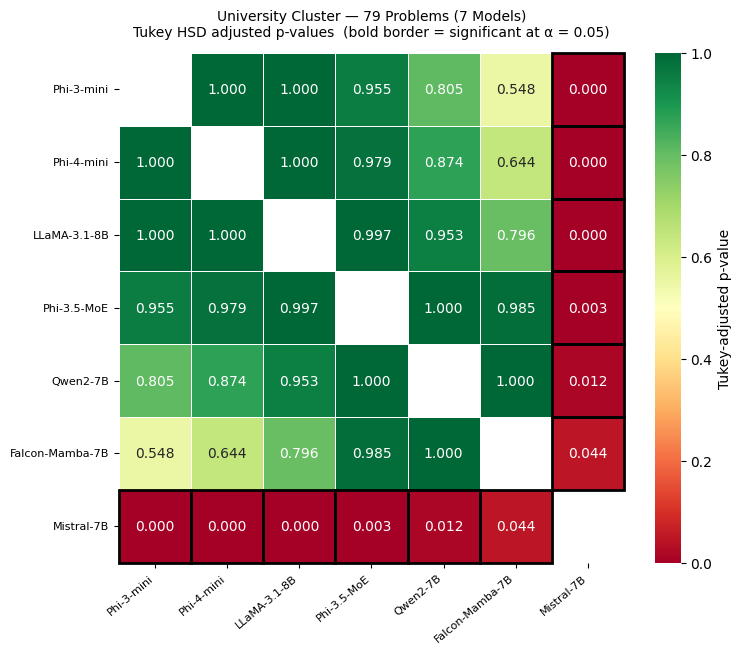

✓ Saved tukey_heatmap_uc.pdf / .png


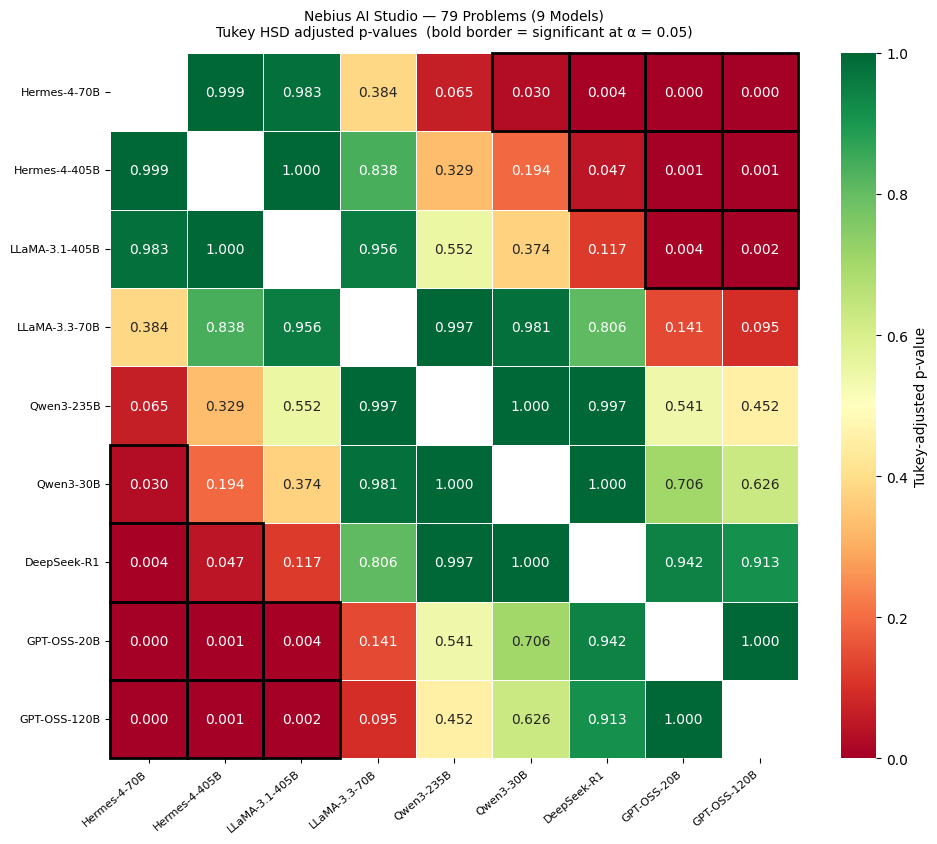

✓ Saved tukey_heatmap_nebius.pdf / .png


In [ ]:
def plot_tukey_heatmap(tukey_df, model_list, title, filename):
    n   = len(model_list)
    idx = {m: i for i, m in enumerate(model_list)}
    p_mat   = np.ones((n, n))
    sig_mat = np.zeros((n, n), dtype=bool)
    for _, row in tukey_df.iterrows():
        a, b = row['Model A'], row['Model B']
        if a in idx and b in idx:
            i, j = idx[a], idx[b]
            p_mat[i,j] = p_mat[j,i] = float(row['p-adj'])
            sig_mat[i,j] = sig_mat[j,i] = bool(row['Reject H0'])

    fig, ax = plt.subplots(figsize=(max(7, n*1.1), max(5, n*0.95)))
    mask = np.eye(n, dtype=bool)
    sns.heatmap(
        p_mat, mask=mask, annot=True, fmt='.3f',
        cmap='RdYlGn', vmin=0, vmax=1,
        xticklabels=model_list, yticklabels=model_list,
        linewidths=0.4, ax=ax,
        cbar_kws={'label': 'Tukey-adjusted p-value'}
    )
    for i in range(n):
        for j in range(n):
            if i != j and sig_mat[i, j]:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1, fill=False,
                    edgecolor='black', lw=2.0, clip_on=False
                ))
    ax.set_title(
        f'{title}\nTukey HSD adjusted p-values  (bold border = significant at α = 0.05)',
        fontsize=10, pad=12
    )
    plt.xticks(rotation=40, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{filename}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'{filename}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"✓ Saved {filename}.pdf / .png")

plot_tukey_heatmap(
    tukey_uc,  list(uc_sorted.keys()),
    'University Cluster — 79 Problems (7 Models)',
    'tukey_heatmap_uc'
)
plot_tukey_heatmap(
    tukey_neb, list(nebius_sorted.keys()),
    'Nebius AI Studio — 79 Problems (9 Models)',
    'tukey_heatmap_nebius'
)

---
## 7. LaTeX Tables — Ready for Manuscript

In [ ]:
def build_latex_table(tukey_df, caption, label):
    sig   = tukey_df[tukey_df['Reject H0']==True].sort_values('p-adj')
    insig = tukey_df[tukey_df['Reject H0']==False].sort_values('p-adj')
    rows  = pd.concat([sig, insig], ignore_index=True)
    lines = [
        r'\begin{table}[h]', r'\centering',
        r'\caption{' + caption + '}',
        r'\label{' + label + '}',
        r'\small',
        r'\begin{adjustbox}{max width=\textwidth}',
        r'\begin{tabular}{llrrrrl}',
        r'\toprule',
        r'\textbf{Model A} & \textbf{Model B} & \textbf{$\Delta$} & \textbf{95\% CI} & \textbf{$p$-adj} & \textbf{Reject $H_0$} & \textbf{Sig.} \\',
        r'\midrule',
    ]
    prev = None
    for _, row in rows.iterrows():
        rej = bool(row['Reject H0'])
        if prev is not None and rej != prev:
            lines.append(r'\midrule')
        prev = rej
        p    = float(row['p-adj'])
        p_s  = r'$<$0.001' if p < 0.001 else f'{p:.3f}'
        ci   = f"[{float(row['CI Lower']):.3f},\\ {float(row['CI Upper']):.3f}]"
        rsym = r'\cmark' if rej else r'\xmark'
        lines.append(
            f"{row['Model A']} & {row['Model B']} & "
            f"${float(row['Mean Diff']):+.4f}$ & {ci} & {p_s} & {rsym} & {row['Sig.']} \\\\"
        )
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{adjustbox}', r'\end{table}']
    return '\n'.join(lines)

print("=" * 70)
print("LaTeX TABLE — University Cluster (t:tukey_uc)")
print("=" * 70)
print(build_latex_table(
    tukey_uc,
    caption=(
        r'Tukey HSD post-hoc pairwise comparisons for the University Cluster '
        r'79-problem benchmark (7 models). $\Delta$ = Model~A $-$ Model~B. '
        r'Adjusted $p$-values control the family-wise error rate at $\alpha=0.05$. '
        r'Rows above the separator are statistically significant.'
    ),
    label='t:tukey_uc'
))

print()
print("=" * 70)
print("LaTeX TABLE — Nebius AI Studio (t:tukey_nebius)")
print("=" * 70)
print(build_latex_table(
    tukey_neb,
    caption=(
        r'Tukey HSD post-hoc pairwise comparisons for the Nebius AI Studio '
        r'79-problem benchmark (9 models). $\Delta$ = Model~A $-$ Model~B. '
        r'Adjusted $p$-values control the family-wise error rate at $\alpha=0.05$. '
        r'Rows above the separator are statistically significant.'
    ),
    label='t:tukey_nebius'
))

LaTeX TABLE — University Cluster (t:tukey_uc)
\begin{table}[h]
\centering
\caption{Tukey HSD post-hoc pairwise comparisons for the University Cluster 79-problem benchmark (7 models). $\Delta$ = Model~A $-$ Model~B. Adjusted $p$-values control the family-wise error rate at $\alpha=0.05$. Rows above the separator are statistically significant.}
\label{t:tukey_uc}
\small
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{llrrrrl}
\toprule
\textbf{Model A} & \textbf{Model B} & \textbf{$\Delta$} & \textbf{95\% CI} & \textbf{$p$-adj} & \textbf{Reject $H_0$} & \textbf{Sig.} \\
\midrule
Mistral-7B & Phi-3-mini & $+0.1769$ & [0.068,\ 0.286] & $<$0.001 & \cmark & *** \\
Mistral-7B & Phi-4-mini & $+0.1717$ & [0.063,\ 0.281] & $<$0.001 & \cmark & *** \\
LLaMA-3.1-8B & Mistral-7B & $-0.1626$ & [-0.272,\ -0.054] & $<$0.001 & \cmark & *** \\
Mistral-7B & Phi-3.5-MoE & $+0.1402$ & [0.031,\ 0.249] & 0.003 & \cmark & ** \\
Mistral-7B & Qwen2-7B & $+0.1256$ & [0.017,\ 0.235] & 0.012 & \cmark & * \\


---
## 8. Summary for Reviewer Response

In [ ]:
print("=" * 80)
print("📋 SUMMARY FOR REVIEWER RESPONSE")
print("=" * 80)

configs = [
    ('University Cluster',  uc_sorted,     F_uc,  p_uc,  tukey_uc,  cld_uc),
    ('Nebius AI Studio',    nebius_sorted,  F_neb, p_neb, tukey_neb, cld_neb),
]

for tag, sdict, F, p, tdf, cld in configs:
    n_pairs = len(tdf)
    n_sig   = int((tdf['Reject H0']==True).sum())
    sig_rows = tdf[tdf['Reject H0']==True].sort_values('p-adj')

    print(f"""
── {tag} ─────────────────────────────────
  ANOVA        : F = {F:.4f},  p = {p:.2e}
  Total pairs  : {n_pairs}
  Significant  : {n_sig}   (Tukey HSD, p-adj < 0.05)
  Non-signif.  : {n_pairs - n_sig}

  Significant pairs (with Cohen's d):""")
    if len(sig_rows) == 0:
        print("    (none)")
    for _, row in sig_rows.iterrows():
        d = cohens_d(sdict[row['Model A']], sdict[row['Model B']])
        print(f"    {row['Model A']:<22} vs {row['Model B']:<22} "
              f"Δ={float(row['Mean Diff']):+.4f}  p-adj={float(row['p-adj']):.4f}  d={d:.2f}")

    top = list(sdict.keys())[0]
    top_letter = ''.join(cld[top])
    equiv = [m for m, v in cld.items() if top_letter in v]
    print(f"""
  Equivalence cluster at the top (letter '{top_letter}'):
    {', '.join(equiv)}
  → These models are NOT significantly different from each other.""")

print("\n" + "=" * 80)

📋 SUMMARY FOR REVIEWER RESPONSE

── University Cluster ─────────────────────────────────
  ANOVA        : F = 5.4907,  p = 1.56e-05
  Total pairs  : 21
  Significant  : 6   (Tukey HSD, p-adj < 0.05)
  Non-signif.  : 15

  Significant pairs (with Cohen's d):
    Mistral-7B             vs Phi-3-mini             Δ=+0.1769  p-adj=0.0000  d=-0.77
    Mistral-7B             vs Phi-4-mini             Δ=+0.1717  p-adj=0.0001  d=-0.75
    LLaMA-3.1-8B           vs Mistral-7B             Δ=-0.1626  p-adj=0.0002  d=0.70
    Mistral-7B             vs Phi-3.5-MoE            Δ=+0.1402  p-adj=0.0029  d=-0.59
    Mistral-7B             vs Qwen2-7B               Δ=+0.1256  p-adj=0.0122  d=-0.52
    Falcon-Mamba-7B        vs Mistral-7B             Δ=-0.1106  p-adj=0.0439  d=0.48

  Equivalence cluster at the top (letter 'a'):
    Phi-3-mini, Phi-4-mini, LLaMA-3.1-8B, Phi-3.5-MoE, Qwen2-7B, Falcon-Mamba-7B
  → These models are NOT significantly different from each other.

── Nebius AI Studio ────────────

---
## 9. Download All Results

In [ ]:
def df_to_records(df):
    return [{
        'model_a'  : row['Model A'],
        'model_b'  : row['Model B'],
        'mean_diff': float(row['Mean Diff']),
        'p_adj'    : float(row['p-adj']),
        'ci_lower' : float(row['CI Lower']),
        'ci_upper' : float(row['CI Upper']),
        'reject_h0': bool(row['Reject H0']),
        'sig'      : row['Sig.']
    } for _, row in df.iterrows()]

output = {
    'university_cluster': {
        'anova'    : {'F': F_uc, 'p': p_uc},
        'tukey_hsd': {'alpha': 0.05,
                      'n_pairs': len(tukey_uc),
                      'n_significant': int((tukey_uc['Reject H0']==True).sum()),
                      'pairs': df_to_records(tukey_uc)},
        'cld'      : {m: ''.join(v) for m, v in cld_uc.items()},
        'means'    : {m: float(np.mean(s)) for m, s in uc_sorted.items()},
    },
    'nebius_ai_studio': {
        'anova'    : {'F': F_neb, 'p': p_neb},
        'tukey_hsd': {'alpha': 0.05,
                      'n_pairs': len(tukey_neb),
                      'n_significant': int((tukey_neb['Reject H0']==True).sum()),
                      'pairs': df_to_records(tukey_neb)},
        'cld'      : {m: ''.join(v) for m, v in cld_neb.items()},
        'means'    : {m: float(np.mean(s)) for m, s in nebius_sorted.items()},
    }
}

with open('tukey_posthoc_results.json', 'w') as f:
    json.dump(output, f, indent=2)
print("✓ Saved tukey_posthoc_results.json")

from google.colab import files as colab_files
for fname in [
    'tukey_posthoc_results.json',
    'tukey_heatmap_uc.pdf', 'tukey_heatmap_uc.png',
    'tukey_heatmap_nebius.pdf', 'tukey_heatmap_nebius.png',
]:
    if os.path.exists(fname):
        colab_files.download(fname)
print("✓ Downloads triggered")

✓ Saved tukey_posthoc_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads triggered
